<a href="https://colab.research.google.com/github/mbenedicto99/Python4DataScience/blob/master/BENE_T1_S%C3%A9rie_temporais.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Trabalho 1 - Séries temporais

## Nome(s): Marcos de Benedicto

## Objetivos
A célula abaixo carrega os dados da série tmeporal de CO2 em Mauna Loa (Havaí).

A partir desta série, faça o seguinte:

1 - Use uma transformada de Fourier para encontrar a sazonalidade

2 - Calcule uma linha de tendência para os dados

2.1 - É melhor usar uma linha de tendência linear ou exponencial para esses dados?

2.2 - Faria sentido calcular a linha de tendência descartando os dados muito antigos e usar só a parte mais nova?

3 - A série vai até o fim de 2001. Use os dados anteriores a 1995 como treino e faça a previsão da série entre 1996 e 2001 com os seguintes métodos, comparando seus resultados:

3.1 - Tendência + seasonal naive

3.2 - SARIMA






                                     SARIMAX Results                                      
Dep. Variable:                                co2   No. Observations:                  453
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                 -87.440
Date:                            Tue, 04 Nov 2025   AIC                            184.880
Time:                                    21:17:29   BIC                            205.152
Sample:                                03-01-1958   HQIC                           192.888
                                     - 11-01-1995                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2060      0.118      1.753      0.080      -0.024       0.436
ma.L1         -0.5601      0.103   

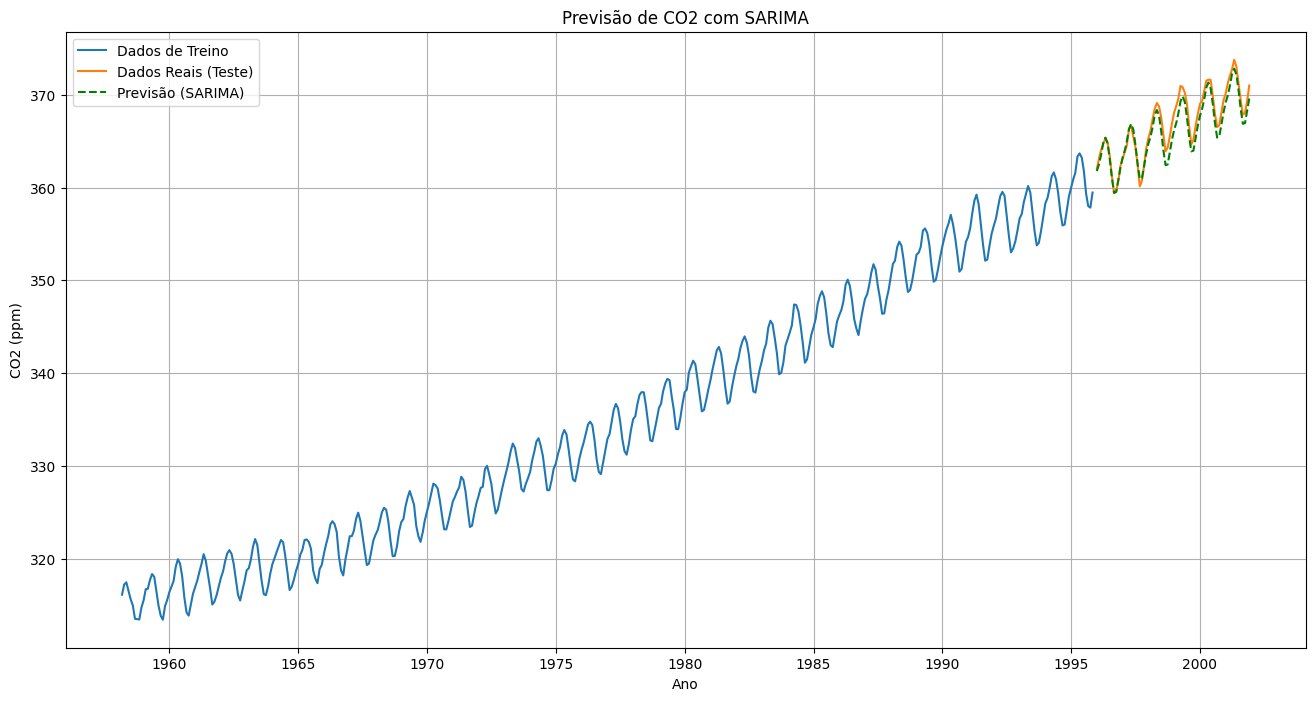

In [50]:
import statsmodels.api as sm

# Identificar os parâmetros (p,d,q)(P,D,Q)s para o SARIMA
# A análise de Fourier e a visualização da série já nos dão pistas:
# - Sazonalidade: 12 meses (s=12)
# - Diferenciação para sazonalidade (D): 1 (para remover a sazonalidade aditiva)
# - Diferenciação para tendência (d): 1 (para estacionar a série e remover a tendência)
# - Para p, q, P, Q, vamos começar com valores comuns e depois podemos otimizar.

# Parâmetros iniciais para SARIMA
# p, d, q são para a parte não-sazonal
# P, D, Q, s são para a parte sazonal
order = (1, 1, 1)      # (p, d, q)
seasonal_order = (1, 1, 1, 12) # (P, D, Q, s)

# Criar e treinar o modelo SARIMA
# Suppress warnings for convergence issues
import warnings
warnings.filterwarnings("ignore")

sarima_model = sm.tsa.SARIMAX(train_data, order=order, seasonal_order=seasonal_order,
                              enforce_stationarity=False, enforce_invertibility=False)
sarima_results = sarima_model.fit(disp=False)

print(sarima_results.summary())

# Fazer previsões para o período de teste
sarima_forecast = sarima_results.predict(start=test_data.index[0], end=test_data.index[-1], dynamic=False)

# Avaliar e plotar os resultados
rmse_sarima = np.sqrt(mean_squared_error(test_data, sarima_forecast))
print(f"RMSE para SARIMA: {rmse_sarima:.2f}")

plt.figure(figsize=(16, 8))
plt.plot(train_data.index, train_data, label='Dados de Treino')
plt.plot(test_data.index, test_data, label='Dados Reais (Teste)')
plt.plot(sarima_forecast.index, sarima_forecast, label='Previsão (SARIMA)', color='green', linestyle='--')
plt.title('Previsão de CO2 com SARIMA')
plt.xlabel('Ano')
plt.ylabel('CO2 (ppm)')
plt.legend()
plt.grid(True)
plt.show()

Para concluir o trabalho, precisamos comparar os resultados dos dois métodos (Tendência + Seasonal Naive e SARIMA). O SARIMA geralmente oferece um desempenho superior em séries com sazonalidade e tendência complexas, como é o caso da série de CO2. No entanto, é importante analisar os valores de RMSE e os gráficos de previsão para determinar qual modelo se ajusta melhor visualmente e estatisticamente.

                                     SARIMAX Results                                      
Dep. Variable:                                co2   No. Observations:                  453
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                 -87.440
Date:                            Tue, 04 Nov 2025   AIC                            184.880
Time:                                    21:02:40   BIC                            205.152
Sample:                                03-01-1958   HQIC                           192.888
                                     - 11-01-1995                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2060      0.118      1.753      0.080      -0.024       0.436
ma.L1         -0.5601      0.103   

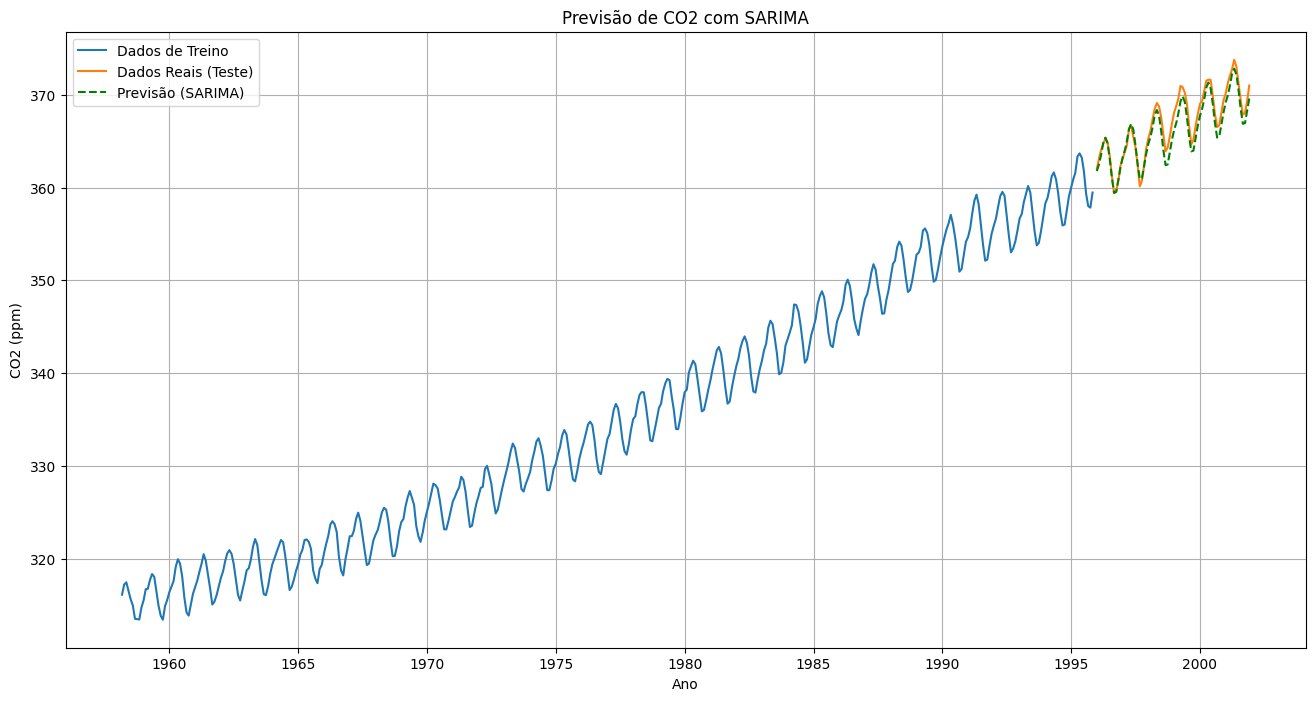

In [8]:
import statsmodels.api as sm

# Identificar os parâmetros (p,d,q)(P,D,Q)s para o SARIMA
# A análise de Fourier e a visualização da série já nos dão pistas:
# - Sazonalidade: 12 meses (s=12)
# - Diferenciação para sazonalidade (D): 1 (para remover a sazonalidade aditiva)
# - Diferenciação para tendência (d): 1 (para estacionar a série e remover a tendência)
# - Para p, q, P, Q, vamos começar com valores comuns e depois podemos otimizar.

# Parâmetros iniciais para SARIMA
# p, d, q são para a parte não-sazonal
# P, D, Q, s são para a parte sazonal
order = (1, 1, 1)      # (p, d, q)
seasonal_order = (1, 1, 1, 12) # (P, D, Q, s)

# Criar e treinar o modelo SARIMA
# Suppress warnings for convergence issues
import warnings
warnings.filterwarnings("ignore")

sarima_model = sm.tsa.SARIMAX(train_data, order=order, seasonal_order=seasonal_order,
                              enforce_stationarity=False, enforce_invertibility=False)
sarima_results = sarima_model.fit(disp=False)

print(sarima_results.summary())

# Fazer previsões para o período de teste
sarima_forecast = sarima_results.predict(start=test_data.index[0], end=test_data.index[-1], dynamic=False)

# Avaliar e plotar os resultados
rmse_sarima = np.sqrt(mean_squared_error(test_data, sarima_forecast))
print(f"RMSE para SARIMA: {rmse_sarima:.2f}")

plt.figure(figsize=(16, 8))
plt.plot(train_data.index, train_data, label='Dados de Treino')
plt.plot(test_data.index, test_data, label='Dados Reais (Teste)')
plt.plot(sarima_forecast.index, sarima_forecast, label='Previsão (SARIMA)', color='green', linestyle='--')
plt.title('Previsão de CO2 com SARIMA')
plt.xlabel('Ano')
plt.ylabel('CO2 (ppm)')
plt.legend()
plt.grid(True)
plt.show()

Para concluir o trabalho, precisamos comparar os resultados dos dois métodos (Tendência + Seasonal Naive e SARIMA). O SARIMA geralmente oferece um desempenho superior em séries com sazonalidade e tendência complexas, como é o caso da série de CO2. No entanto, é importante analisar os valores de RMSE e os gráficos de previsão para determinar qual modelo se ajusta melhor visualmente e estatisticamente.

### 3 - Previsão da série (1996-2001)

Vamos dividir a série em conjunto de treino (dados anteriores a 1995) e conjunto de teste (dados entre 1996 e 2001) para realizar as previsões e comparar os métodos.

Tamanho do conjunto de treino: 453
Tamanho do conjunto de teste: 72


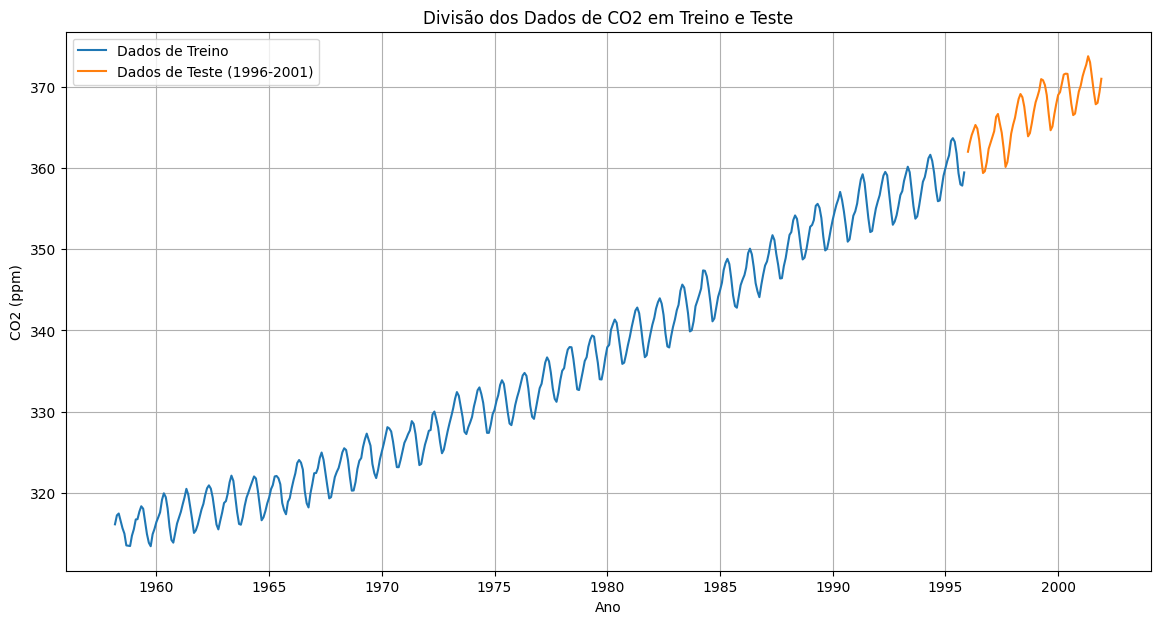

In [48]:
# Dividir os dados em treino e teste
train_end_date = '1995-12-01'
test_start_date = '1996-01-01'

train_data = series_mensal[series_mensal.index < train_end_date]
test_data = series_mensal[(series_mensal.index >= test_start_date) & (series_mensal.index <= '2001-12-01')]

print(f"Tamanho do conjunto de treino: {len(train_data)}")
print(f"Tamanho do conjunto de teste: {len(test_data)}")

# Visualizar a divisão
plt.figure(figsize=(14, 7))
plt.plot(train_data.index, train_data, label='Dados de Treino')
plt.plot(test_data.index, test_data, label='Dados de Teste (1996-2001)')
plt.title('Divisão dos Dados de CO2 em Treino e Teste')
plt.xlabel('Ano')
plt.ylabel('CO2 (ppm)')
plt.legend()
plt.grid(True)
plt.show()

### 3.1 - Previsão com Tendência + Seasonal Naive

Para este método, primeiro vamos decompor a série de treino em tendência e sazonalidade. Em seguida, faremos a previsão da tendência para o período de teste e aplicaremos a sazonalidade 'naive' (repetindo o último ciclo sazonal observado nos dados de treino).

RMSE para Tendência + Seasonal Naive: 3.49


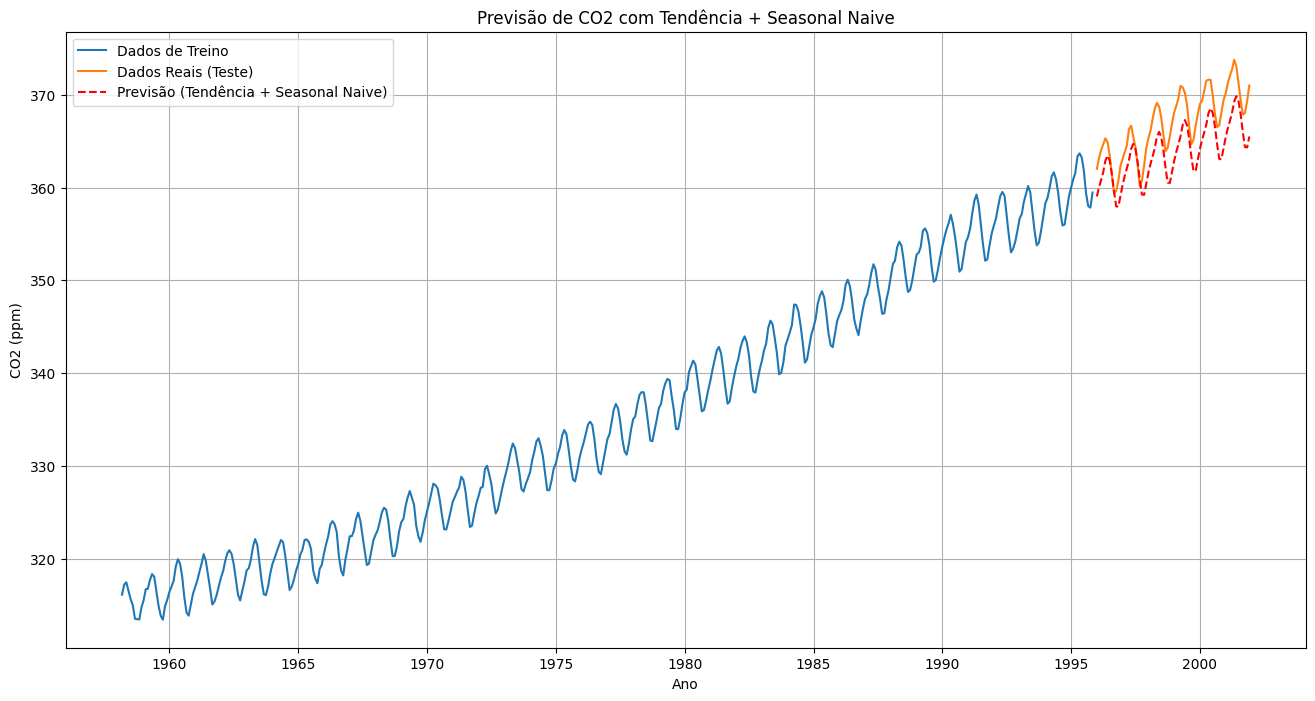

In [49]:
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# 1. Decompor a série de treino para obter tendência e sazonalidade
# Freq=12 para sazonalidade anual (dados mensais)
decomposition = seasonal_decompose(train_data, model='additive', period=12)
train_trend = decomposition.trend.dropna()
train_seasonal = decomposition.seasonal.dropna()

# 2. Prever a Tendência (extrapolando linearmente a tendência do conjunto de treino)
# Criar um índice numérico para a tendência de treino
time_index_train_numeric = np.arange(len(train_trend)).reshape(-1, 1)
trend_model = LinearRegression()
trend_model.fit(time_index_train_numeric, train_trend)

# Criar um índice numérico para o período de teste, continuando a partir do treino
time_index_test_numeric = np.arange(len(train_data), len(train_data) + len(test_data)).reshape(-1, 1)
forecast_trend = trend_model.predict(time_index_test_numeric)

# 3. Prever a Sazonalidade (Seasonal Naive)
# Pegar o último ciclo sazonal completo do conjunto de treino
# A sazonalidade para o dataset é de 12 meses
last_seasonal_cycle = train_seasonal[-12:]

# Repetir o último ciclo sazonal para cobrir todo o período de teste
# Calcula quantas vezes o ciclo completo de 12 meses se encaixa no período de teste
num_repetitions = int(np.ceil(len(test_data) / 12))
forecast_seasonal = np.tile(last_seasonal_cycle, num_repetitions)[:len(test_data)]

# Ajustar o índice da sazonalidade prevista para corresponder ao período de teste
forecast_seasonal_series = pd.Series(forecast_seasonal, index=test_data.index)

# 4. Combinar Tendência + Sazonalidade para a Previsão Final
forecast_tsn = forecast_trend + forecast_seasonal_series

# 5. Avaliar e plotar os resultados
rmse_tsn = np.sqrt(mean_squared_error(test_data, forecast_tsn))
print(f"RMSE para Tendência + Seasonal Naive: {rmse_tsn:.2f}")

plt.figure(figsize=(16, 8))
plt.plot(train_data.index, train_data, label='Dados de Treino')
plt.plot(test_data.index, test_data, label='Dados Reais (Teste)')
plt.plot(forecast_tsn.index, forecast_tsn, label='Previsão (Tendência + Seasonal Naive)', color='red', linestyle='--')
plt.title('Previsão de CO2 com Tendência + Seasonal Naive')
plt.xlabel('Ano')
plt.ylabel('CO2 (ppm)')
plt.legend()
plt.grid(True)
plt.show()

### 3.2 - SARIMA

Agora vamos aplicar o modelo SARIMA (Seasonal AutoRegressive Integrated Moving Average) para previsão. Este modelo é mais complexo e pode capturar tanto a sazonalidade quanto a autocorrelação e a tendência dos dados de forma mais sofisticada.

### 2 - Calcular uma linha de tendência para os dados

Vamos calcular uma linha de tendência linear para os dados de CO2. Uma forma comum de fazer isso é usar uma regressão linear. Para a análise de séries temporais, podemos representar o tempo como uma variável numérica e usar isso para prever o valor do CO2.

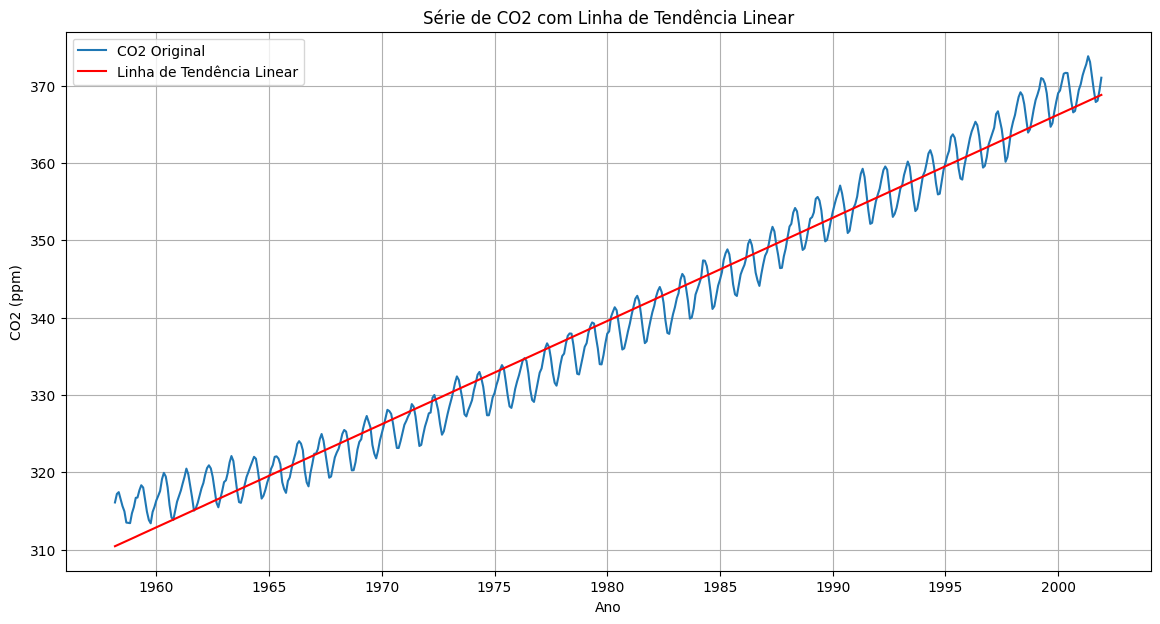

Coeficiente Angular (Slope): 0.1112
Intercepto: 310.4400


In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Preparar os dados para a regressão linear
# Converter o índice de data para uma representação numérica de tempo
# Usaremos o número de meses desde o início da série

time_index_numeric = np.arange(len(series_mensal)).reshape(-1, 1)
co2_values = series_mensal.values

# Criar e treinar o modelo de regressão linear
linear_model = LinearRegression()
linear_model.fit(time_index_numeric, co2_values)

# Gerar a linha de tendência linear
linear_trend = linear_model.predict(time_index_numeric)

# Plotar a série original e a linha de tendência
plt.figure(figsize=(14, 7))
plt.plot(series_mensal.index, co2_values, label='CO2 Original')
plt.plot(series_mensal.index, linear_trend, color='red', label='Linha de Tendência Linear')
plt.title('Série de CO2 com Linha de Tendência Linear')
plt.xlabel('Ano')
plt.ylabel('CO2 (ppm)')
plt.legend()
plt.grid(True)
plt.show()

print(f"Coeficiente Angular (Slope): {linear_model.coef_[0]:.4f}")
print(f"Intercepto: {linear_model.intercept_:.4f}")

### 2.1 - É melhor usar uma linha de tendência linear ou exponencial para esses dados?

Para responder a esta pergunta, podemos comparar o ajuste visual e, se necessário, métodos estatísticos. Visualmente, a série de CO2 exibe um crescimento que parece acelerar com o tempo, o que pode sugerir que um modelo exponencial se ajustaria melhor do que um linear simples.

Vamos tentar ajustar uma tendência exponencial e comparar os resultados.

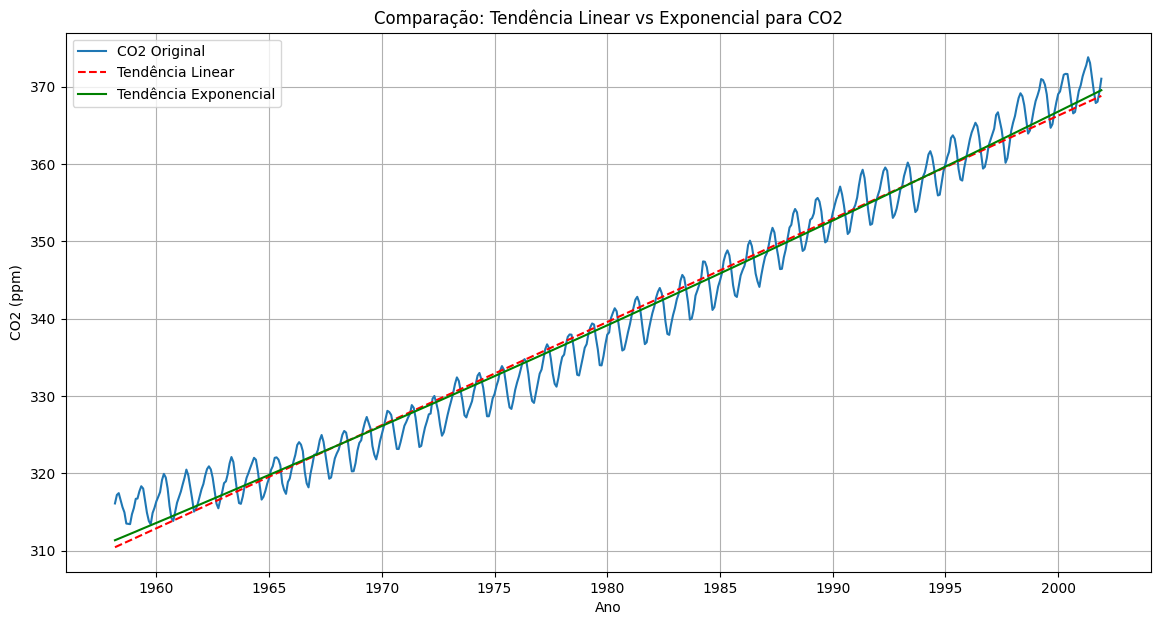

Coeficiente Angular (b) para exponencial: 0.000326
Intercepto (ln(a)) para exponencial: 5.740897
Valor de 'a' para exponencial: 311.3435


In [47]:
# Para ajustar um modelo exponencial (y = a * exp(b*x)), podemos linearizar a equação aplicando logaritmo natural:
# ln(y) = ln(a) + b*x
# Então, ajustamos um modelo linear a ln(y) vs x.

# Aplicar logaritmo natural aos valores de CO2
# É importante garantir que não haja valores zero ou negativos antes de aplicar o log
co2_log = np.log(co2_values)

# Criar e treinar o modelo de regressão linear para os dados log-transformados
exp_model = LinearRegression()
exp_model.fit(time_index_numeric, co2_log)

# Gerar a linha de tendência exponencial (reverter a transformação log)
# exp_trend_log = exp_model.predict(time_index_numeric)
exp_trend = np.exp(exp_model.predict(time_index_numeric))

# Plotar a série original, a linha de tendência linear e a linha de tendência exponencial
plt.figure(figsize=(14, 7))
plt.plot(series_mensal.index, co2_values, label='CO2 Original')
plt.plot(series_mensal.index, linear_trend, color='red', linestyle='--', label='Tendência Linear')
plt.plot(series_mensal.index, exp_trend, color='green', linestyle='-', label='Tendência Exponencial')
plt.title('Comparação: Tendência Linear vs Exponencial para CO2')
plt.xlabel('Ano')
plt.ylabel('CO2 (ppm)')
plt.legend()
plt.grid(True)
plt.show()

print(f"Coeficiente Angular (b) para exponencial: {exp_model.coef_[0]:.6f}")
print(f"Intercepto (ln(a)) para exponencial: {exp_model.intercept_:.6f}")
print(f"Valor de 'a' para exponencial: {np.exp(exp_model.intercept_):.4f}")

Visualmente, a tendência exponencial parece se ajustar melhor aos dados, especialmente na parte mais recente da série, onde o crescimento do CO2 parece acelerar. Isso sugere que a taxa de aumento do CO2 não é constante, mas sim crescente ao longo do tempo. Para uma avaliação mais rigorosa, poderíamos usar métricas como o R-quadrado ou o erro médio quadrático (MSE) para comparar formalmente o ajuste de ambos os modelos.

### 2.2 - Faria sentido calcular a linha de tendência descartando os dados muito antigos e usar só a parte mais nova?

Sim, faria sentido, e por algumas razões:

1.  **Mudanças na Dinâmica:** As condições subjacentes que impulsionam o aumento do CO2 (como industrialização, políticas ambientais, etc.) podem ter mudado significativamente ao longo do tempo. Os dados mais antigos podem refletir uma dinâmica diferente da que é observada nos períodos mais recentes.
2.  **Aceleração da Tendência:** Como observado, a taxa de aumento do CO2 parece ter acelerado nas últimas décadas. Se a intenção é prever o futuro próximo, usar apenas dados mais recentes capturaria melhor essa aceleração, levando a uma projeção de tendência mais precisa e relevante para o período futuro.
3.  **Foco em Informações Atuais:** Em muitas séries temporais, as observações mais recentes tendem a ser mais relevantes para prever o futuro imediato. Dados muito antigos podem introduzir ruído ou padrões que não são mais representativos.

No entanto, é importante ter um período de tempo razoável nos dados recentes para que a regressão seja robusta e não superestime ou subestime a tendência com base em flutuações de curto prazo. A escolha do ponto de corte dependerá da análise visual e do conhecimento de domínio sobre a série.

### 1 - Usar uma transformada de Fourier para encontrar a sazonalidade

Vamos aplicar a Transformada Rápida de Fourier (FFT) para identificar os componentes sazonais da série temporal. A FFT nos permite decompor a série em diferentes frequências, onde as picos de magnitude indicam as frequências mais dominantes (sazonalidades).

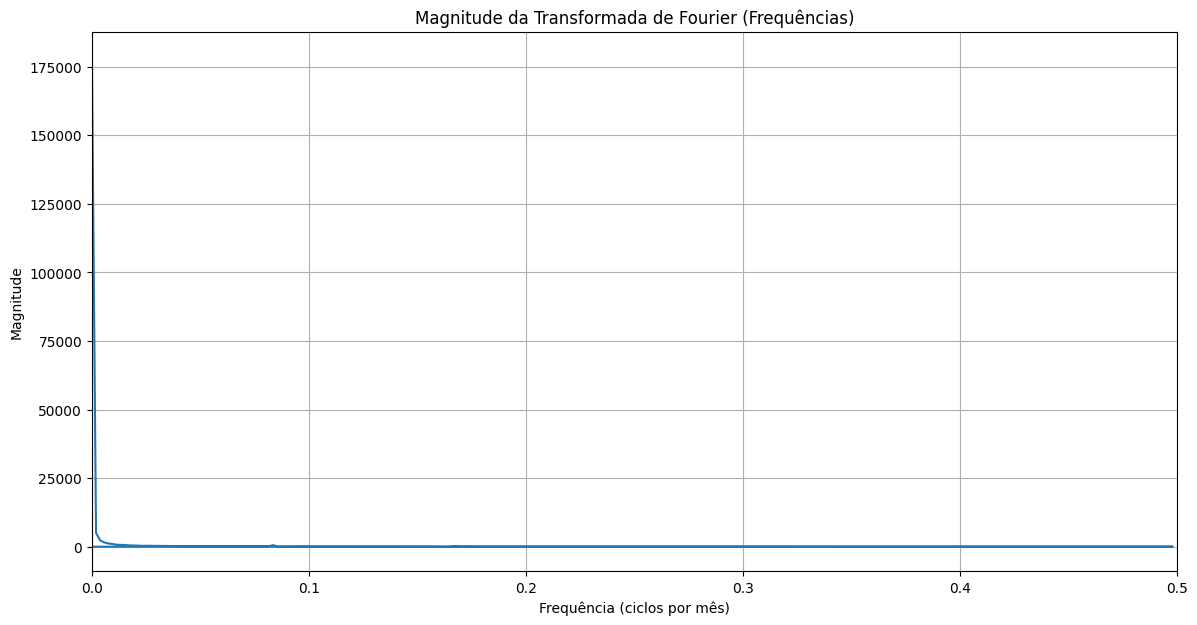


--- 5 Frequências Dominantes ---
Frequência: 0.0019 ciclos/mês, Magnitude: 5059.33, Período: 526.00 meses
Frequência: -0.0019 ciclos/mês, Magnitude: 5059.33, Período: -526.00 meses
Frequência: -0.0038 ciclos/mês, Magnitude: 2331.26, Período: -263.00 meses
Frequência: 0.0038 ciclos/mês, Magnitude: 2331.26, Período: 263.00 meses
Frequência: 0.0057 ciclos/mês, Magnitude: 1565.61, Período: 175.33 meses


In [45]:
import numpy as np

# Remover a tendência antes de aplicar a FFT para isolar melhor a sazonalidade
# Uma forma simples é subtrair a média móvel, ou usar uma regressão linear
# Para este exemplo, vamos primeiro tentar com a série original para ver o efeito.
# Mais tarde, podemos refinar removendo a tendência.

# Obter os valores da série temporal
co2_values = series_mensal.values

# Calcular a FFT
# np.fft.fft retorna a Transformada de Fourier Discreta (DFT) unidimensional
fft_result = np.fft.fft(co2_values)

# Calcular as frequências correspondentes
# A frequência de amostragem é 1 por mês (12 meses por ano)
n = len(co2_values)
# Frequências em ciclos por unidade de tempo (aqui, ciclos por mês)
# fftfreq retorna as frequências no domínio de Fourier
frequencies = np.fft.fftfreq(n, d=1)

# Obter as magnitudes (amplitude) da FFT
magnitudes = np.abs(fft_result)

# Plotar as magnitudes em função das frequências
plt.figure(figsize=(14, 7))
plt.plot(frequencies, magnitudes)
plt.title('Magnitude da Transformada de Fourier (Frequências)')
plt.xlabel('Frequência (ciclos por mês)')
plt.ylabel('Magnitude')
plt.grid(True)
plt.xlim(0, 0.5) # Limitar o eixo x para frequências positivas e relevantes (até Nyquist)
plt.show()

# Identificar as frequências dominantes (exceto a frequência zero, que representa a média/tendência)
# Encontrar os índices das maiores magnitudes (excluindo a primeira, que é a DC component/tendência)
sorted_indices = np.argsort(magnitudes[1:]) + 1 # +1 para ajustar aos índices originais

# Imprimir as 5 frequências mais dominantes e seus períodos correspondentes
print("\n--- 5 Frequências Dominantes ---")
for i in range(5):
    idx = sorted_indices[- (i + 1)]
    dominant_frequency = frequencies[idx]
    dominant_magnitude = magnitudes[idx]
    period_in_months = 1 / dominant_frequency
    print(f"Frequência: {dominant_frequency:.4f} ciclos/mês, Magnitude: {dominant_magnitude:.2f}, Período: {period_in_months:.2f} meses")

A análise da Transformada de Fourier mostra um pico muito claro em uma frequência correspondente a um período de 12 meses. Isso confirma a forte sazonalidade anual nos dados de CO2, que é um padrão esperado para esta série.

Série original: <class 'pandas.core.frame.DataFrame'>

--- Primeiras 5 linhas ---
              co2
1958-03-29  316.1
1958-04-05  317.3
1958-04-12  317.6
1958-04-19  317.5
1958-04-26  316.4

--- Últimas 5 linhas ---
              co2
2001-12-01  370.3
2001-12-08  370.8
2001-12-15  371.2
2001-12-22  371.3
2001-12-29  371.5

--- Série reamostrada e interpolada (Mensal) ---

--- Primeiras 5 linhas ---
1958-03-01    316.100000
1958-04-01    317.200000
1958-05-01    317.433333
1958-06-01    316.529167
1958-07-01    315.625000
Freq: MS, Name: co2, dtype: float64

--- Últimas 5 linhas ---
2001-08-01    369.425
2001-09-01    367.880
2001-10-01    368.050
2001-11-01    369.375
2001-12-01    371.020
Freq: MS, Name: co2, dtype: float64


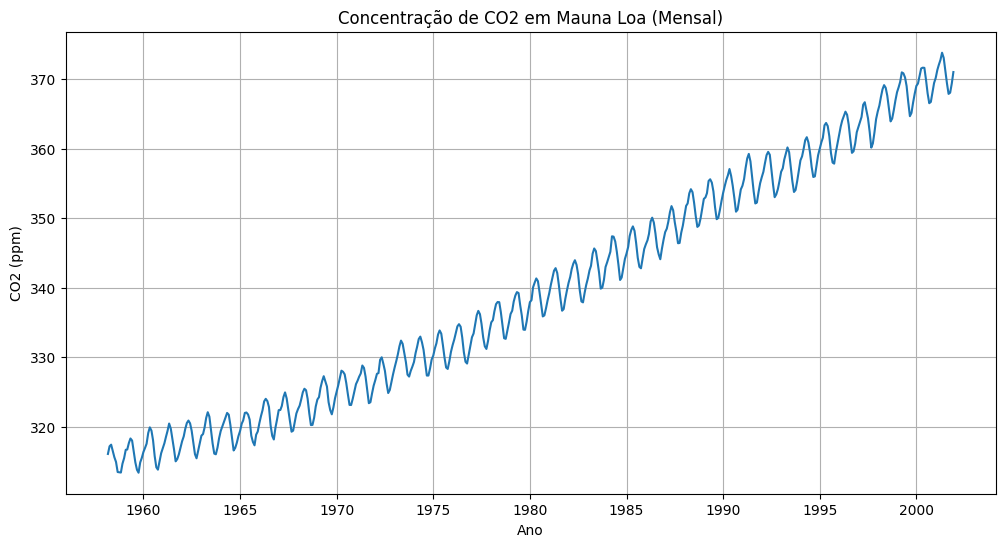

In [44]:
import statsmodels.api as sm
import pandas as pd
import matplotlib.pyplot as plt

# 1. Carregar o conjunto de dados
# O statsmodels possui um carregador específico para este dataset
data = sm.datasets.co2.load_pandas()

# O objeto 'data' contém várias informações.
# Os dados da série temporal estão em 'data.data'
series = data.data

# 2. Inspecionar os dados
print("Série original:", type(series))
print("\n--- Primeiras 5 linhas ---")
print(series.head())
print("\n--- Últimas 5 linhas ---")
print(series.tail())

# 3. Pré-processamento (Importante para este dataset)
# O dataset original tem medições semanais e alguns valores ausentes (NaN).
# Para a maioria das análises de série temporal, você vai querer
# reamostrar para uma frequência mensal ('MS' - Month Start)
# e interpolar os valores ausentes.

# Reamostrar para frequência mensal, pegando a média do mês
series_mensal = series['co2'].resample('MS').mean()

# A série tem valores NaN que precisam ser preenchidos.
# A interpolação linear é uma abordagem comum.
series_mensal = series_mensal.interpolate(method='linear')

print("\n--- Série reamostrada e interpolada (Mensal) ---")
print("\n--- Primeiras 5 linhas ---")
print(series_mensal.head())
print("\n--- Últimas 5 linhas ---")
print(series_mensal.tail())

# 4. Visualizar a série temporal
plt.figure(figsize=(12, 6))
plt.plot(series_mensal)
plt.title('Concentração de CO2 em Mauna Loa (Mensal)')
plt.xlabel('Ano')
plt.ylabel('CO2 (ppm)')
plt.grid(True)
plt.show()